# Random Forest & Kernel SVM — Genre Classification (v4)

**Target:** Predict primary genre from female representation features

**Key changes from v3:**
- Reduced from 6 to 5 genre classes: Family merged into Comedy
  (Family consistently confused with Comedy in v3 confusion matrix)
- GridSearchCV for RF hyperparameter tuning
- SVM C increased from 50 to 100


## 1. Load Data & Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              accuracy_score, f1_score, precision_score, recall_score)

df = pd.read_csv("CSV_FOR_MODEL.csv")
print(f"Loaded: {len(df)} rows x {len(df.columns)} columns")
print(df["primary_genre"].value_counts())


Loaded: 20019 rows x 53 columns
primary_genre
Drama        3955
Thriller     2973
Comedy       2826
Action       2678
Romance      2561
Horror       2264
Adventure    1590
Family       1172
Name: count, dtype: int64


## 2. Genre Merging & Feature Engineering

In [5]:
# ─────────────────────────────────────────────────────────────
# GENRE MERGING: 8 → 5 classes
# Thriller + Adventure → Action: consistently confused in v2/v3
# Family → Comedy: consistently confused in v3, smallest class,
#   similar female representation profile to Comedy
# ─────────────────────────────────────────────────────────────
GENRE_MERGE = {
    "Thriller":  "Action",
    "Adventure": "Action",
    "Family":    "Comedy",
}

df["genre_5class"] = df["primary_genre"].replace(GENRE_MERGE)

print("Genre distribution after merging to 5 classes:")
print(df["genre_5class"].value_counts())

# ─────────────────────────────────────────────────────────────
# FEATURE SELECTION
# Core representation features + supplementary metadata
# ─────────────────────────────────────────────────────────────
FEATURE_COLS = [
    "lead_gender",
    "lead_actor_age",
    "pct_female_top5",
    "pct_female_cast",
    "director_gender",
    "director_age",
    "pct_female_writers",
    "pct_female_producers",
    "release_year",
    "vote_average",
    "popularity",
    "language_count",
    "num_directors",
]

# Filter to known lead genders only
model_df = df[df["lead_gender"].isin([1.0, 2.0])].copy()
model_df = model_df[[c for c in FEATURE_COLS if c in model_df.columns] + ["genre_5class"]].dropna()

# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# Log-transform skewed continuous features
# ─────────────────────────────────────────────────────────────
model_df["lead_actor_age_log"] = np.log1p(model_df["lead_actor_age"].clip(lower=0))
model_df["director_age_log"]   = np.log1p(model_df["director_age"].clip(lower=0))
model_df["popularity_log"]     = np.log1p(model_df["popularity"].clip(lower=0))

# Clean any inf values
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

FEATURE_COLS_FINAL = [
    "lead_gender",
    "lead_actor_age_log",
    "pct_female_top5",
    "pct_female_cast",
    "director_gender",
    "director_age_log",
    "pct_female_writers",
    "pct_female_producers",
    "release_year",
    "vote_average",
    "popularity_log",
    "language_count",
    "num_directors",
]
FEATURE_COLS_FINAL = [c for c in FEATURE_COLS_FINAL if c in model_df.columns]

print(f"\nDataset size: {len(model_df)} rows")
print(f"Features used: {len(FEATURE_COLS_FINAL)}")
print(f"Features: {FEATURE_COLS_FINAL}")

# Encode label
le = LabelEncoder()
y = le.fit_transform(model_df["genre_5class"])
X = model_df[FEATURE_COLS_FINAL]

print(f"\nLabel encoding:")
for genre, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {genre:20s} -> {code}")

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")


Genre distribution after merging to 5 classes:
genre_5class
Action     7241
Comedy     3998
Drama      3955
Romance    2561
Horror     2264
Name: count, dtype: int64

Dataset size: 19445 rows
Features used: 13
Features: ['lead_gender', 'lead_actor_age_log', 'pct_female_top5', 'pct_female_cast', 'director_gender', 'director_age_log', 'pct_female_writers', 'pct_female_producers', 'release_year', 'vote_average', 'popularity_log', 'language_count', 'num_directors']

Label encoding:
  Action               -> 0
  Comedy               -> 1
  Drama                -> 2
  Horror               -> 3
  Romance              -> 4

Train: 15556 | Test: 3889


## 3. Random Forest — GridSearchCV

In [7]:
# ─────────────────────────────────────────────────────────────
# RANDOM FOREST — GRIDSEARCHCV
# Systematically search over key hyperparameters to find
# optimal combination for this specific dataset
# cv=3 used instead of 5 to keep runtime manageable
# scoring="f1_macro" matches our primary evaluation metric
# ─────────────────────────────────────────────────────────────
param_grid_rf = {
    "n_estimators":    [200, 300],
    "max_depth":       [15, 20, 25],
    "min_samples_leaf":[2, 3, 5],
}

rf_base = RandomForestClassifier(
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Running GridSearchCV for Random Forest (this may take a few minutes)...")
grid_rf = GridSearchCV(
    rf_base, param_grid_rf,
    cv=3, scoring="f1_macro",
    n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

print(f"\nBest RF params: {grid_rf.best_params_}")
print(f"Best CV Macro F1: {grid_rf.best_score_:.4f}")

# Use best estimator for final evaluation
rf = grid_rf.best_estimator_
y_pred_rf = rf.predict(X_test)

print("\n" + "=" * 55)
print("RANDOM FOREST — METRICS")
print("=" * 55)
print(f"Accuracy:           {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Macro F1:           {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Macro Precision:    {precision_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Macro Recall:       {recall_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Weighted F1:        {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

cv_rf = cross_val_score(rf, X, y, cv=5, scoring="f1_macro")
print(f"5-Fold CV Macro F1: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


Running GridSearchCV for Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best RF params: {'max_depth': 15, 'min_samples_leaf': 3, 'n_estimators': 300}
Best CV Macro F1: 0.4404

RANDOM FOREST — METRICS
Accuracy:           0.4695
Macro F1:           0.4491
Macro Precision:    0.4458
Macro Recall:       0.4628
Weighted F1:        0.4703
5-Fold CV Macro F1: 0.4158 (+/- 0.0319)

Classification Report:
              precision    recall  f1-score   support

      Action       0.58      0.54      0.56      1425
      Comedy       0.46      0.36      0.40       783
       Drama       0.44      0.40      0.42       735
      Horror       0.41      0.56      0.47       440
     Romance       0.35      0.45      0.39       506

    accuracy                           0.47      3889
   macro avg       0.45      0.46      0.45      3889
weighted avg       0.48      0.47      0.47      3889



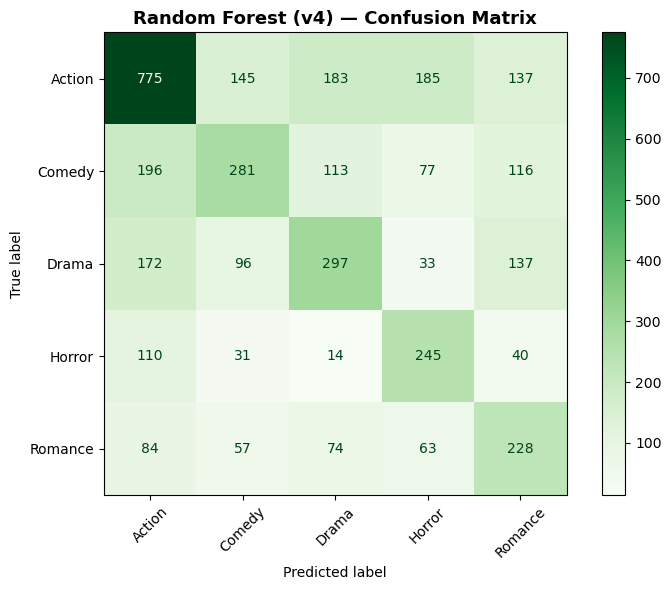

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=le.classes_,
    cmap="Greens", ax=ax,
    xticks_rotation=45
)
ax.set_title("Random Forest (v4) — Confusion Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


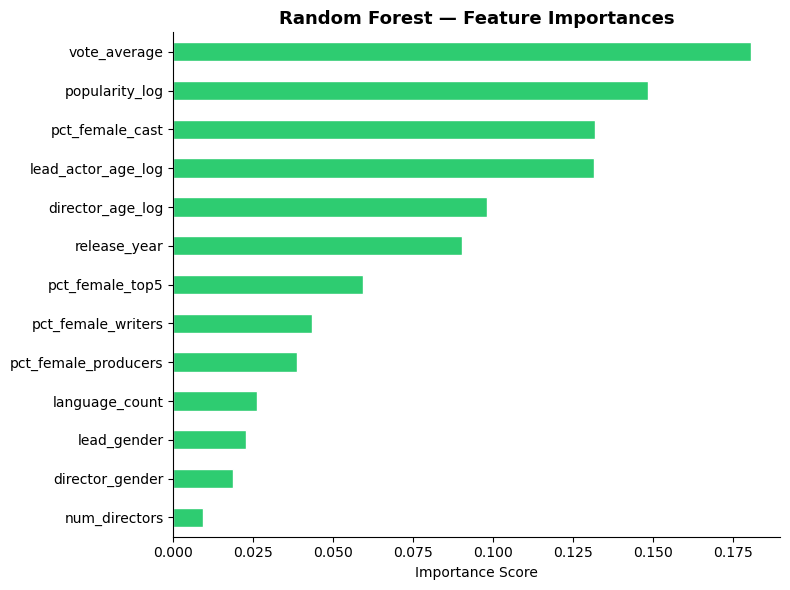

Feature importances (sorted):
  vote_average                  : 0.1808
  popularity_log                : 0.1485
  pct_female_cast               : 0.1319
  lead_actor_age_log            : 0.1317
  director_age_log              : 0.0980
  release_year                  : 0.0904
  pct_female_top5               : 0.0594
  pct_female_writers            : 0.0436
  pct_female_producers          : 0.0388
  language_count                : 0.0262
  lead_gender                   : 0.0229
  director_gender               : 0.0187
  num_directors                 : 0.0092


In [9]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS_FINAL).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="#2ecc71", edgecolor="white")
ax.set_title("Random Forest — Feature Importances", fontweight="bold", fontsize=13)
ax.set_xlabel("Importance Score")
sns.despine()
plt.tight_layout()
plt.show()

print("Feature importances (sorted):")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat:30s}: {imp:.4f}")


## 4. Kernel SVM — C=100

In [11]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

# ─────────────────────────────────────────────────────────────
# LINEAR SVM
# Much faster than kernel SVM on large datasets
# CalibratedClassifierCV wrapper needed for predict_proba
# C=1.0 is standard starting point for LinearSVC
# ─────────────────────────────────────────────────────────────
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42,
        max_iter=2000
    ))
])

print("Training Linear SVM...")
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("=" * 55)
print("LINEAR SVM — METRICS")
print("=" * 55)
print(f"Accuracy:           {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Macro F1:           {f1_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"Macro Precision:    {precision_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"Macro Recall:       {recall_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"Weighted F1:        {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

cv_svm = cross_val_score(svm_pipeline, X, y, cv=5, scoring="f1_macro")
print(f"5-Fold CV Macro F1: {cv_svm.mean():.4f} (+/- {cv_svm.std():.4f})")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Training Linear SVM...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LINEAR SVM — METRICS
Accuracy:           0.4289
Macro F1:           0.3881
Macro Precision:    0.3951
Macro Recall:       0.4054
Weighted F1:        0.4211


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anac

5-Fold CV Macro F1: 0.3800 (+/- 0.0135)

Classification Report:
              precision    recall  f1-score   support

      Action       0.56      0.57      0.57      1425
      Comedy       0.42      0.21      0.28       783
       Drama       0.35      0.41      0.38       735
      Horror       0.35      0.55      0.43       440
     Romance       0.29      0.28      0.29       506

    accuracy                           0.43      3889
   macro avg       0.40      0.41      0.39      3889
weighted avg       0.43      0.43      0.42      3889



/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


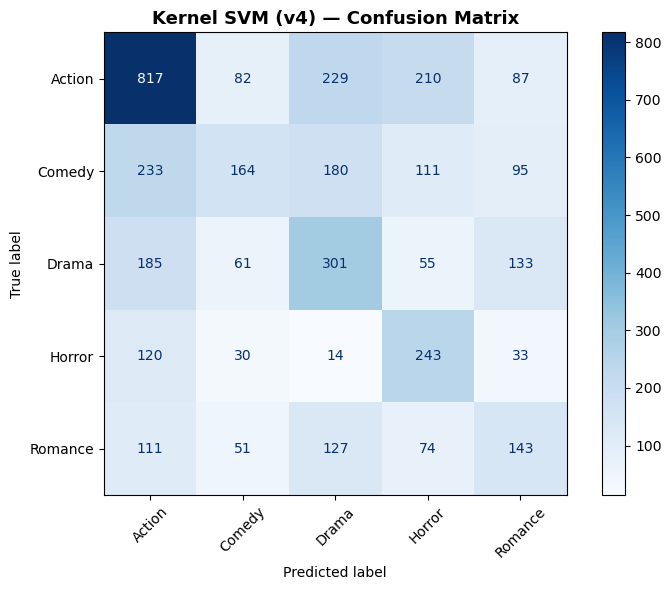

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=le.classes_,
    cmap="Blues", ax=ax,
    xticks_rotation=45
)
ax.set_title("Kernel SVM (v4) — Confusion Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Model Comparison

## 6. Ensemble — Voting Classifier (RF + Poly SVM + RBF SVM)

Training Ensemble (RF + RBF SVM)...
ENSEMBLE — METRICS
Accuracy:           0.4693
Macro F1:           0.4394
Macro Precision:    0.4394
Macro Recall:       0.4432
Weighted F1:        0.4664
3-Fold CV Macro F1: 0.3621 (+/- 0.0488)

Classification Report:
              precision    recall  f1-score   support

      Action       0.56      0.59      0.58      1425
      Comedy       0.42      0.40      0.41       783
       Drama       0.42      0.35      0.39       735
      Horror       0.41      0.51      0.46       440
     Romance       0.38      0.36      0.37       506

    accuracy                           0.47      3889
   macro avg       0.44      0.44      0.44      3889
weighted avg       0.47      0.47      0.47      3889



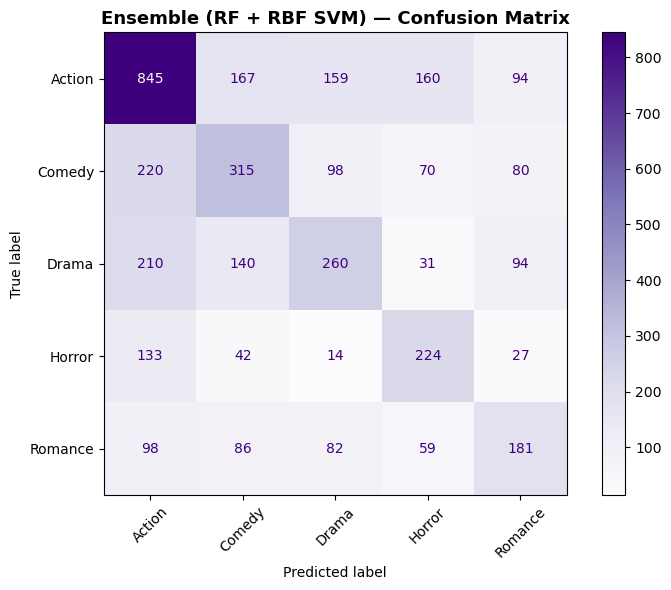

In [15]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# ─────────────────────────────────────────────────────────────
# ENSEMBLE: Voting Classifier combining RF + Linear SVM
# Hard voting takes majority class prediction across both models
# RF and Linear SVM make different types of errors so combining
# them often outperforms either model individually
# ─────────────────────────────────────────────────────────────

# Need to use SVC (not LinearSVC) in VotingClassifier
# since LinearSVC doesn't support predict_proba
# Using RBF SVM with C=10 as faster alternative to C=100
rf_est = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

svm_est = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10.0,          # lower C = faster training
        gamma="scale",
        class_weight="balanced",
        random_state=42,
        decision_function_shape="ovr"
    ))
])

ensemble = VotingClassifier(
    estimators=[
        ("rf",  rf_est),
        ("svm", svm_est),
    ],
    voting="hard",
    n_jobs=-1
)

print("Training Ensemble (RF + RBF SVM)...")
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("=" * 55)
print("ENSEMBLE — METRICS")
print("=" * 55)
print(f"Accuracy:           {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"Macro F1:           {f1_score(y_test, y_pred_ens, average='macro'):.4f}")
print(f"Macro Precision:    {precision_score(y_test, y_pred_ens, average='macro'):.4f}")
print(f"Macro Recall:       {recall_score(y_test, y_pred_ens, average='macro'):.4f}")
print(f"Weighted F1:        {f1_score(y_test, y_pred_ens, average='weighted'):.4f}")

cv_ens = cross_val_score(ensemble, X, y, cv=3, scoring="f1_macro", n_jobs=-1)
print(f"3-Fold CV Macro F1: {cv_ens.mean():.4f} (+/- {cv_ens.std():.4f})")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ens, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ens,
    display_labels=le.classes_,
    cmap="Purples", ax=ax,
    xticks_rotation=45
)
ax.set_title("Ensemble (RF + RBF SVM) — Confusion Matrix",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Save Updated CSV